# 03 - ACF & ADF TEST - FTT & S&P 500

## 0. Thiết lập

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from dotenv import load_dotenv
from supabase import create_client

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / ".env").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
load_dotenv(PROJECT_ROOT / ".env")

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_PUBLISHABLE_KEY")
if not SUPABASE_URL or not SUPABASE_KEY:
    raise RuntimeError("Không tìm thấy SUPABASE_URL hoặc SUPABASE_PUBLISHABLE_KEY trong .env")

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)
START_DATE = pd.Timestamp("2021-01-01")
END_DATE = pd.Timestamp("2025-01-01")  # exclusive
FTT_TICKER = "FTT-USD"
SP500_TICKER = "^GSPC"

print("Research period:", START_DATE.date(), "->", (END_DATE - pd.Timedelta(days=1)).date())


Research period: 2021-01-01 -> 2024-12-31


In [2]:
def get_asset(ticker):
    response = (
        supabase.table("assets")
        .select("asset_id, ticker, asset_name, asset_type, data_source")
        .eq("ticker", ticker).limit(1).execute()
    )
    if not response.data:
        raise RuntimeError(f"Không tìm thấy asset {ticker} trong bảng assets.")
    return response.data[0]


REQUIRED_COLUMNS = ["price_id", "asset_id", "trade_date", "open_price", "high_price",
                     "low_price", "close_price", "volume", "created_at"]
PAGE_SIZE = 1000


def fetch_daily_prices(asset_id, ticker):
    rows, start = [], 0
    while True:
        response = (
            supabase.table("daily_prices")
            .select("price_id, asset_id, trade_date, open_price, high_price, low_price, close_price, volume, created_at")
            .eq("asset_id", asset_id)
            .gte("trade_date", START_DATE.strftime("%Y-%m-%d"))
            .lt("trade_date", END_DATE.strftime("%Y-%m-%d"))
            .order("trade_date", desc=False)
            .range(start, start + PAGE_SIZE - 1)
            .execute()
        )
        batch = response.data or []
        rows.extend(batch)
        if len(batch) < PAGE_SIZE:
            break
        start += PAGE_SIZE

    df = pd.DataFrame(rows, columns=REQUIRED_COLUMNS)
    if df.empty:
        raise RuntimeError(f"Không có dữ liệu cho {ticker}.")
    df["trade_date"] = pd.to_datetime(df["trade_date"], errors="coerce")
    for col in ["open_price", "high_price", "low_price", "close_price", "volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.sort_values("trade_date", kind="stable").reset_index(drop=True)


def preprocess_price_data(df, name):
    data = df.copy()
    data["trade_date"] = pd.to_datetime(data["trade_date"], errors="coerce")
    data = data[data["trade_date"].between(START_DATE, END_DATE - pd.Timedelta(days=1), inclusive="both")].copy()
    data = data.dropna(subset=["trade_date"])
    data = data.sort_values("trade_date", kind="stable")
    data = data.drop_duplicates(subset=["trade_date"], keep="first")
    invalid_close = data["close_price"].isna() | ~np.isfinite(data["close_price"]) | (data["close_price"] <= 0)
    data = data.loc[~invalid_close].reset_index(drop=True)
    return data


def add_returns(df, price_col, prefix, check_daily_continuity=False):
    data = df.copy()
    data[f"{prefix}_simple_return"] = data[price_col].pct_change()
    data[f"{prefix}_log_return"] = np.log(data[price_col] / data[price_col].shift(1))
    if check_daily_continuity:
        day_diff = data["trade_date"].diff().dt.days
        gap_mask = day_diff > 1
        data.loc[gap_mask, [f"{prefix}_simple_return", f"{prefix}_log_return"]] = np.nan
    return data


ftt_asset = get_asset(FTT_TICKER)
sp500_asset = get_asset(SP500_TICKER)

ftt_raw = fetch_daily_prices(ftt_asset["asset_id"], FTT_TICKER)
sp500_raw = fetch_daily_prices(sp500_asset["asset_id"], SP500_TICKER)

ftt_processed = preprocess_price_data(ftt_raw, "FTT")
sp500_processed = preprocess_price_data(sp500_raw, "S&P 500")

ftt_processed = add_returns(ftt_processed, "close_price", "FTT", True)
sp500_processed = add_returns(sp500_processed, "close_price", "SP500", False)

ftt_min = ftt_processed["trade_date"].min().date()
ftt_max = ftt_processed["trade_date"].max().date()
sp_min = sp500_processed["trade_date"].min().date()
sp_max = sp500_processed["trade_date"].max().date()
print(f"FTT processed:    {ftt_processed.shape}  ({ftt_min} -> {ftt_max})")
print(f"S&P500 processed: {sp500_processed.shape}  ({sp_min} -> {sp_max})")


FTT processed:    (1461, 11)  (2021-01-01 -> 2024-12-31)
S&P500 processed: (1005, 11)  (2021-01-04 -> 2024-12-31)


## 0.1. Định nghĩa event window (FTX sụp đổ)

In [3]:
# Event window chính: FTX sụp đổ 02/11 - 11/11/2022
EVENT_START = pd.Timestamp("2022-11-02")
EVENT_END = pd.Timestamp("2022-11-11")
EVENT_DATE = pd.Timestamp("2022-11-08")  # ngày FTX tạm dừng rút ti

VIEW_START = pd.Timestamp("2022-10-01")
VIEW_END = pd.Timestamp("2022-12-31")

print("Event window (FTX collapse):", EVENT_START.date(), "->", EVENT_END.date())


Event window (FTX collapse): 2022-11-02 -> 2022-11-11


## 1. ACF trên chuỗi giá (level)

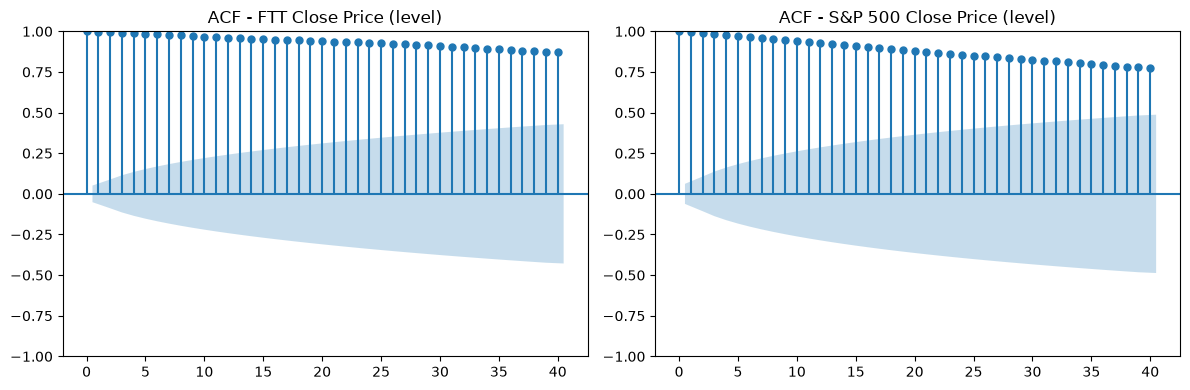

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ftt_processed["close_price"].dropna(), lags=40, ax=axes[0])
axes[0].set_title("ACF - FTT Close Price (level)")

plot_acf(sp500_processed["close_price"].dropna(), lags=40, ax=axes[1])
axes[1].set_title("ACF - S&P 500 Close Price (level)")

plt.tight_layout()
plt.show()

## 2. ACF trên log return

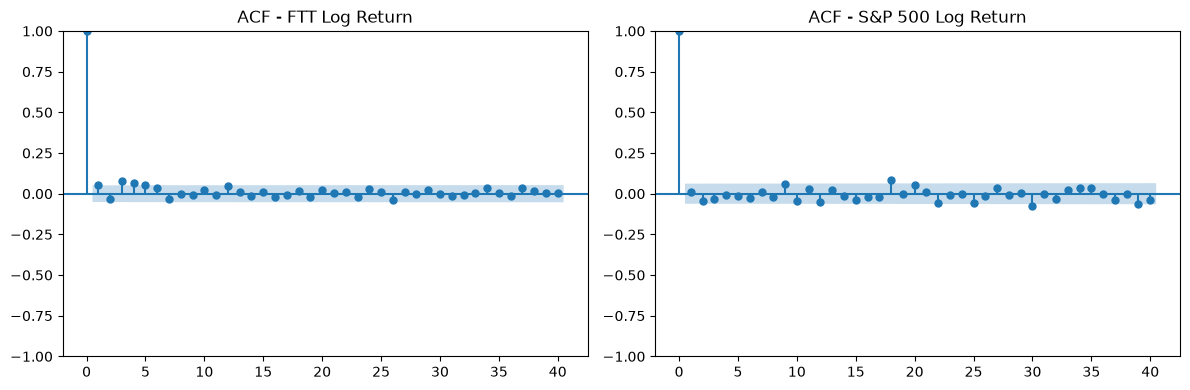

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ftt_processed["FTT_log_return"].dropna(), lags=40, ax=axes[0])
axes[0].set_title("ACF - FTT Log Return")

plot_acf(sp500_processed["SP500_log_return"].dropna(), lags=40, ax=axes[1])
axes[1].set_title("ACF - S&P 500 Log Return")

plt.tight_layout()
plt.show()

## 3. ADF test (Augmented Dickey-Fuller)

In [6]:
def adf_test(series, name):
    s = series.dropna()
    result = adfuller(s, autolag="AIC")
    statistic, pvalue, used_lag, nobs, crit_values = result[0], result[1], result[2], result[3], result[4]
    return {
        "series": name,
        "adf_statistic": statistic,
        "p_value": pvalue,
        "used_lag": used_lag,
        "n_obs": nobs,
        "crit_1%": crit_values["1%"],
        "crit_5%": crit_values["5%"],
        "crit_10%": crit_values["10%"],
        "stationary_at_5%": pvalue < 0.05,
    }

adf_results = pd.DataFrame([
    adf_test(ftt_processed["close_price"], "FTT - Price (level)"),
    adf_test(ftt_processed["FTT_log_return"], "FTT - Log Return"),
    adf_test(sp500_processed["close_price"], "S&P 500 - Price (level)"),
    adf_test(sp500_processed["SP500_log_return"], "S&P 500 - Log Return"),
])
display(adf_results)

C:\Users\Admin\AppData\Local\Temp\ipykernel_8660\790221654.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(s, autolag="AIC")
C:\Users\Admin\AppData\Local\Temp\ipykernel_8660\790221654.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(s, autolag="AIC")
C:\Users\Admin\AppData\Local\Temp\ipykernel_8660\790221654.py:3: FutureWarning: 

,series,adf_statistic,p_value,used_lag,n_obs,crit_1%,crit_5%,crit_10%,stationary_at_5%
0,FTT - Price (level),-1.221858,6.641228e-01,17,1443,-3.434890,-2.863545,-2.567837,False
1,FTT - Log Return,-14.850764,1.778611e-27,4,1455,-3.434852,-2.863528,-2.567829,True
2,S&P 500 - Price (level),-0.497413,8.925204e-01,0,1004,-3.436880,-2.864423,-2.568305,False
3,S&P 500 - Log Return,-23.257334,0.000000e+00,1,1002,-3.436893,-2.864429,-2.568308,True


## 4. ADF test theo giai đoạn (trước vs trong+sau sự kiện FTX) - riêng cho FTT

In [7]:
ftt_before = ftt_processed[ftt_processed["trade_date"] < EVENT_DATE]
ftt_after = ftt_processed[ftt_processed["trade_date"] >= EVENT_DATE]

adf_period_results = pd.DataFrame([
    adf_test(ftt_before["FTT_log_return"], "FTT Log Return - trước 08/11/2022"),
    adf_test(ftt_after["FTT_log_return"], "FTT Log Return - từ 08/11/2022"),
])
display(adf_period_results)

print("Std log return trước sự kiện:", round(ftt_before["FTT_log_return"].std(), 4))
print("Std log return từ sự kiện:   ", round(ftt_after["FTT_log_return"].std(), 4))
print("Số quan sát trước / sau:", len(ftt_before), "/", len(ftt_after))

C:\Users\Admin\AppData\Local\Temp\ipykernel_8660\790221654.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(s, autolag="AIC")
C:\Users\Admin\AppData\Local\Temp\ipykernel_8660\790221654.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(s, autolag="AIC")


,series,adf_statistic,p_value,used_lag,n_obs,crit_1%,crit_5%,crit_10%,stationary_at_5%
0,FTT Log Return - trước 08/11/2022,-27.203012,0.0,0,674,-3.440089,-2.865838,-2.569059,True
1,FTT Log Return - từ 08/11/2022,-29.801449,0.0,0,784,-3.438718,-2.865234,-2.568737,True


Std log return trước sự kiện: 0.0534
Std log return từ sự kiện:    0.1001
Số quan sát trước / sau: 676 / 785


## Kết luận

### 1. Bậc tích hợp của chuỗi thời gian

Kết quả ACF cho thấy chuỗi giá đóng cửa của FTT và S&P 500 suy giảm rất chậm, cho thấy giá có mức phụ thuộc cao vào các giá trị trong quá khứ. Đồng thời, kiểm định ADF cho `p-value` lần lượt là **0.6641** và **0.8925**, đều lớn hơn 0.05. Vì vậy, hai chuỗi giá đều không dừng và phù hợp với bậc tích hợp **I(1)**.

Đối với Log Return, ACF giảm nhanh về gần 0 và kiểm định ADF cho `p-value` gần **0.0000**, với ADF Statistic là **-14.85** đối với FTT và **-23.26** đối với S&P 500. Do đó, Log Return là chuỗi dừng, phù hợp với **I(0)**.

### 2. Tác động của sự kiện FTX

Kết quả ADF cho thấy Log Return của FTT vẫn dừng ở cả hai giai đoạn trước và sau ngày 08/11/2022, với `p-value = 0.0`. Tuy nhiên, độ lệch chuẩn tăng từ **0.0534** lên **0.1001**, tương đương mức tăng **1.87 lần**. Điều này cho thấy sự kiện FTX không làm mất tính dừng của Log Return nhưng làm mức độ biến động và rủi ro của FTT tăng mạnh.

### 3. Hàm ý cho mô hình dự báo

Do chuỗi giá gốc là **I(1)** và không dừng, việc sử dụng trực tiếp chuỗi này cho các mô hình dự báo có thể dẫn đến kết quả không ổn định và hồi quy giả. Vì vậy, cần chuyển đổi giá sang **Log Return I(0)** trước khi thực hiện các phân tích hoặc xây dựng mô hình chuỗi thời gian như **ARMA, GARCH** và các mô hình Machine Learning.
